<a href="https://colab.research.google.com/github/huynhhoc/DataAnalystDeepLearning/blob/main/cnn_feature_map_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Feature Map Visualization

Notebook này minh họa:

- Xây dựng một mô hình CNN đơn giản bằng PyTorch.
- Train mô hình trên dataset `digits` có sẵn trong `scikit-learn`.
- Lấy và hiển thị **feature map** của một ảnh mẫu sau từng layer CNN.

Dataset dùng ảnh chữ số grayscale kích thước `8x8`, gồm 10 lớp: `0` đến `9`.

## 1. Import thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Cấu hình tham số

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001
NUM_CLASSES = 10

print('Using device:', DEVICE)

Using device: cpu


## 3. Load dataset digits

Ảnh ban đầu có shape `[N, 8, 8]`.

CNN trong PyTorch cần input có shape `[N, C, H, W]`, nên ta đổi thành `[N, 1, 8, 8]`.

In [3]:
digits = load_digits()

X = digits.images
y = digits.target

# Chuẩn hóa pixel từ khoảng 0..16 về 0..1
X = X / 16.0
X = X.astype(np.float32)

# Thêm chiều channel: [N, 8, 8] -> [N, 1, 8, 8]
X = X[:, None, :, :]
y = y.astype(np.int64)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Classes:', np.unique(y))

X shape: (1797, 1, 8, 8)
y shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


## 4. Hiển thị một vài ảnh mẫu

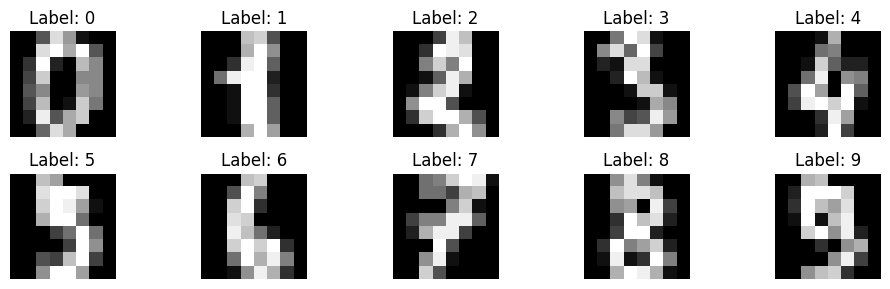

In [4]:
plt.figure(figsize=(10, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Chia train/test và tạo DataLoader

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Train size:', len(train_dataset))
print('Test size:', len(test_dataset))

Train size: 1437
Test size: 360


## 6. Xây dựng mô hình CNN

Kiến trúc:

```text
Input image 1x8x8
  ↓
Conv1: 1 channel -> 8 channels
  ↓
ReLU
  ↓
MaxPool: 8x8 -> 4x4
  ↓
Conv2: 8 channels -> 16 channels
  ↓
ReLU
  ↓
MaxPool: 4x4 -> 2x2
  ↓
Flatten
  ↓
Fully Connected
  ↓
Output 10 classes
```

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)

        return x


model = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


## 7. Train CNN

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total

    if (epoch + 1) % 5 == 0:
        print(
            f'Epoch [{epoch + 1}/{EPOCHS}], '
            f'Loss: {total_loss / len(train_loader):.4f}, '
            f'Train Acc: {train_acc:.4f}'
        )

Epoch [5/20], Loss: 1.6096, Train Acc: 0.5692
Epoch [10/20], Loss: 0.5147, Train Acc: 0.8573
Epoch [15/20], Loss: 0.2916, Train Acc: 0.9235
Epoch [20/20], Loss: 0.2127, Train Acc: 0.9402


## 8. Đánh giá trên test set

In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        outputs = model(X_batch)
        predicted = torch.argmax(outputs, dim=1)

        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

test_acc = correct / total
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9139


## 9. Lấy feature map sau từng layer

Feature map là output trung gian của ảnh sau khi đi qua các layer như `Conv`, `ReLU`, `Pooling`.

Trong ví dụ này, ta lưu feature map tại:

- `conv1`
- `relu1`
- `pool1`
- `conv2`
- `relu2`
- `pool2`

In [9]:
def get_feature_maps(model, image_tensor):
    """
    image_tensor shape: [1, 1, 8, 8]
    Trả về dict chứa feature map sau từng layer quan trọng.
    """

    model.eval()

    feature_maps = {}

    with torch.no_grad():
        x = image_tensor.to(DEVICE)

        x = model.conv1(x)
        feature_maps['conv1'] = x.cpu()

        x = model.relu1(x)
        feature_maps['relu1'] = x.cpu()

        x = model.pool1(x)
        feature_maps['pool1'] = x.cpu()

        x = model.conv2(x)
        feature_maps['conv2'] = x.cpu()

        x = model.relu2(x)
        feature_maps['relu2'] = x.cpu()

        x = model.pool2(x)
        feature_maps['pool2'] = x.cpu()

    return feature_maps

## 10. Hàm visualize feature map

Mỗi layer có nhiều channel. Mỗi channel có thể hiểu là một filter đang nhìn ảnh theo một kiểu đặc trưng riêng.

In [10]:
def plot_feature_maps(feature_maps, original_image, true_label, max_channels=8):
    num_layers = len(feature_maps)

    plt.figure(figsize=(14, 3 * (num_layers + 1)))

    # Vẽ ảnh gốc
    plt.subplot(num_layers + 1, max_channels, 1)
    plt.imshow(original_image.squeeze(), cmap='gray')
    plt.title(f'Original\nLabel: {true_label}')
    plt.axis('off')

    row = 1

    for layer_name, fmap in feature_maps.items():
        # fmap shape: [1, C, H, W]
        fmap = fmap.squeeze(0)
        num_channels = fmap.shape[0]
        channels_to_show = min(num_channels, max_channels)

        for i in range(channels_to_show):
            plt.subplot(num_layers + 1, max_channels, row * max_channels + i + 1)
            plt.imshow(fmap[i], cmap='viridis')
            plt.title(f'{layer_name}\nch {i}')
            plt.axis('off')

        row += 1

    plt.tight_layout()
    plt.show()

## 11. Chọn một ảnh mẫu và hiển thị feature map

conv1 shape: (1, 8, 8, 8)
relu1 shape: (1, 8, 8, 8)
pool1 shape: (1, 8, 4, 4)
conv2 shape: (1, 16, 4, 4)
relu2 shape: (1, 16, 4, 4)
pool2 shape: (1, 16, 2, 2)


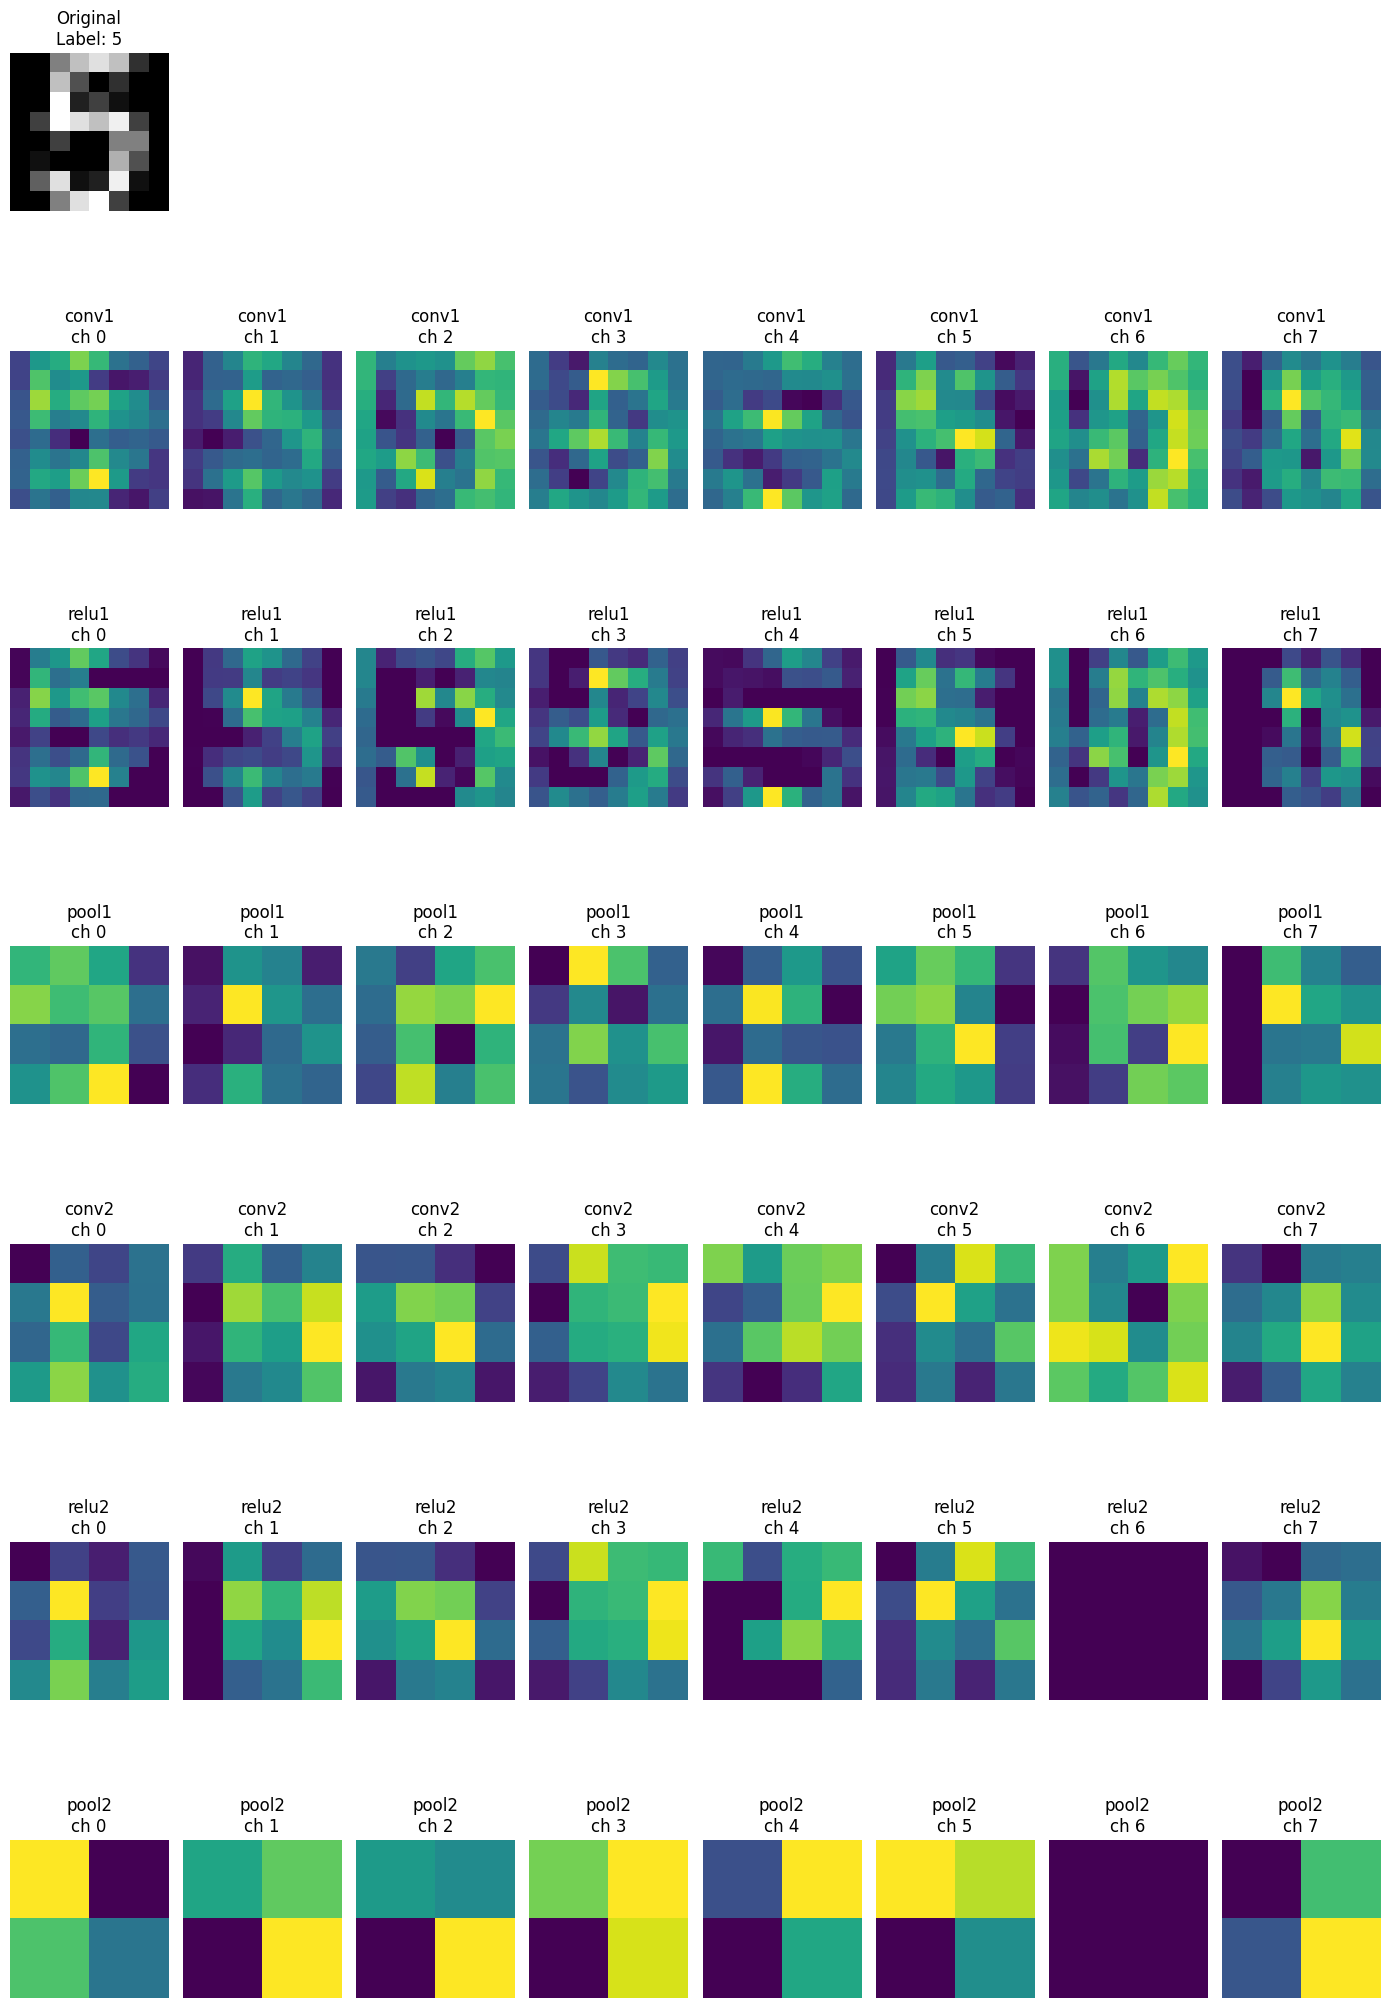

In [11]:
sample_index = 0

sample_image = X_test[sample_index:sample_index + 1]
sample_label = y_test[sample_index].item()

feature_maps = get_feature_maps(model, sample_image)

for layer_name, fmap in feature_maps.items():
    print(layer_name, 'shape:', tuple(fmap.shape))

plot_feature_maps(
    feature_maps,
    original_image=sample_image.numpy(),
    true_label=sample_label,
    max_channels=8
)

## 12. Giải thích

- `conv1`: tạo ra nhiều bản đồ đặc trưng từ ảnh gốc. Mỗi channel tương ứng với một filter khác nhau.
- `relu1`: loại bỏ giá trị âm, giữ lại vùng kích hoạt mạnh.
- `pool1`: giảm kích thước ảnh đặc trưng, giữ thông tin nổi bật.
- `conv2`: học đặc trưng sâu hơn từ feature map tầng trước.
- `relu2`: tiếp tục giữ vùng kích hoạt quan trọng.
- `pool2`: tiếp tục giảm kích thước để đưa vào fully connected layer.
